In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

from pathlib import Path

def _abs_parquet(rel):
    """Resolve a path relative to src/notebooks and return the absolute parquet path."""
    here = Path.cwd().resolve()
    data = None
    for candidate in (here, *here.parents):
        if (candidate / 'src' / 'data').is_dir() and (candidate / 'src' / 'notebooks').is_dir():
            data = candidate / 'src' / 'data'
            break
        if candidate.name == 'notebooks' and (candidate.parent / 'data').is_dir():
            data = (candidate.parent / 'data').resolve()
            break
    if data is None:
        raise FileNotFoundError(f'Could not locate src/data from {here}')
    path = (data / rel.removeprefix('../data/')).resolve()
    matches = list(path.parent.glob(path.name)) if '*' in path.name else ([path] if path.is_file() else [])
    if not matches:
        raise FileNotFoundError(path)
    return str(path)

repos_path = _abs_parquet('../data/gitskills_data/data/repos/*.parquet')
artifacts_path = _abs_parquet('../data/gitskills_data/data/artifacts/*.parquet')
artifact_siblings_path = _abs_parquet('../data/gitskills_data/data/artifact_siblings/*.parquet')
mining_runs_path = _abs_parquet('../data/gitskills_data/data/mining_runs/*.parquet')
skill_features_path = _abs_parquet('../data/generated_data/skill_features.parquet')
file_agents_path = _abs_parquet('../data/generated_data/file_agents.parquet')

con = duckdb.connect(database=':memory:')

## Content and structure

Readable population and structural features of skill bodies.


In [2]:
population = con.execute(f"""
SELECT COUNT(*)                                                    AS distinct_skills,
       COUNT_IF(content IS NULL OR content = '')                   AS no_text,
       COUNT_IF(strpos(content, chr(10)) = 0
                AND content LIKE '%SKILL.md')                      AS symlink_stubs,
       COUNT_IF(content LIKE 'Redirecting%')                       AS redirects,
       COUNT_IF(NOT frontmatter_valid)                             AS invalid_frontmatter,
       COUNT_IF(body_chars < 200)                                  AS short_body,
       COUNT_IF(first_commit_at < '2025-10-01')                    AS pre_format_history,
       COUNT_IF(content IS NOT NULL AND content <> ''
                AND NOT (strpos(content, chr(10)) = 0 AND content LIKE '%SKILL.md')
                AND content NOT LIKE 'Redirecting%'
                AND frontmatter_valid
                AND body_chars >= 200)                             AS kept
FROM read_parquet('{artifacts_path}')
WHERE dedup_primary = 1;
""").df()
population

,distinct_skills,no_text,symlink_stubs,redirects,invalid_frontmatter,short_body,pre_format_history,kept
0,1877981,0.0,5247.0,1.0,252280.0,37108.0,152.0,1601100.0


## Population

Of 1,877,981 distinct skills, none lack text. We remove 5,247 symlink stubs
(files whose content is only a path to another `SKILL.md`), one saved redirect
page, and skills with a body under 200 characters (placeholders and
front-matter-only files). Invalid YAML front matter affects 252,280 skills
(13.4%), far more than any other rule. Because broken front matter does not
make a file any less a skill, and validity is itself a potential authorship
signal, we report two populations: readable skills (quality filters only) and
valid skills (also requiring valid front matter, 1,601,100 or 85.3%). Each
analysis states which it uses.

In [3]:
invalid_fm = con.execute(f"""
SELECT CASE WHEN NOT regexp_matches(content, '^\\s*---')           THEN 'no front matter block'
            WHEN coalesce(name, '') = '' AND coalesce(description, '') = '' THEN 'block present, no name or description'
            WHEN coalesce(name, '') = ''                             THEN 'missing name'
            WHEN coalesce(description, '') = ''                      THEN 'missing description'
            ELSE 'other (YAML error or rule violation)' END AS reason,
       COUNT(*) AS skills, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM read_parquet('{artifacts_path}')
WHERE dedup_primary = 1 AND NOT frontmatter_valid
GROUP BY 1 ORDER BY skills DESC
""").df()
invalid_fm

,reason,skills,pct
0,no front matter block,171480,68.0
1,"block present, no name or description",49938,19.8
2,missing name,23060,9.1
3,missing description,7802,3.1


#### Structural features

Structural features of the readable population (deduplicated skills with a body of at least 200 characters, excluding symlink stubs and the saved redirect) are stored in `skill_features.parquet`. The summaries below cover length, markdown structure, and front-matter fields.


In [4]:
structure = con.execute(f"""
SELECT COUNT(*)                                            AS skills,
       quantile_cont(body_words, [.1, .25, .5, .75, .9])  AS body_words_p10_p25_p50_p75_p90,
       quantile_cont(desc_chars, [.1, .5, .9])            AS desc_chars_p10_p50_p90,
       median(headings)                                    AS median_headings,
       ROUND(AVG((headings = 0)::INT), 3)                  AS share_no_headings,
       ROUND(AVG((numbered_items > 0)::INT), 3)            AS share_numbered_steps,
       ROUND(AVG((bullet_items > 0)::INT), 3)              AS share_bullets,
       ROUND(AVG((code_blocks > 0)::INT), 3)               AS share_code_blocks,
       ROUND(AVG((table_rows > 0)::INT), 3)                AS share_tables,
       ROUND(AVG((links > 0)::INT), 3)                     AS share_links,
       ROUND(AVG(has_examples_section::INT), 3)            AS share_examples_section,
       ROUND(AVG(has_when_to_use::INT), 3)                 AS share_when_to_use,
       ROUND(AVG(fm_allowed_tools::INT), 3)                AS share_fm_allowed_tools,
       ROUND(AVG(fm_license::INT), 3)                      AS share_fm_license,
       ROUND(AVG(fm_version_or_metadata::INT), 3)          AS share_fm_version_metadata,
       ROUND(AVG((non_ascii_ratio > 0.2)::INT), 3)         AS share_mostly_non_english
FROM '{skill_features_path}';
""").df()
structure.T.rename(columns={0: "value"})


,value
skills,1840872
body_words_p10_p25_p50_p75_p90,"[142.0, 306.0, 639.0, 1183.0, 1995.0]"
desc_chars_p10_p50_p90,"[0.0, 188.0, 478.0]"
median_headings,12.0
share_no_headings,0.017
share_numbered_steps,0.699
share_bullets,0.94
share_code_blocks,0.68
share_tables,0.442
share_links,0.205


In [5]:
structure_by_location = con.execute(f"""
SELECT location_class, COUNT(*) AS skills,
       median(body_words)                          AS median_words,
       median(headings)                            AS median_headings,
       ROUND(AVG((code_blocks > 0)::INT), 3)       AS share_code_blocks,
       ROUND(AVG(has_examples_section::INT), 3)    AS share_examples_section,
       ROUND(AVG(has_when_to_use::INT), 3)         AS share_when_to_use
FROM '{skill_features_path}'
GROUP BY 1 ORDER BY skills DESC;
""").df()
structure_by_location


,location_class,skills,median_words,median_headings,share_code_blocks,share_examples_section,share_when_to_use
0,skills-dir,1019877,620.0,11.0,0.651,0.217,0.246
1,other,554589,636.0,13.0,0.690,0.245,0.293
2,canonical,266406,710.0,13.0,0.769,0.157,0.173


In [6]:
body_length = con.execute(f"""
SELECT CASE WHEN body_words < 100 THEN '<100' WHEN body_words < 250 THEN '100-249'
            WHEN body_words < 500 THEN '250-499' WHEN body_words < 1000 THEN '500-999'
            WHEN body_words < 2000 THEN '1000-1999' WHEN body_words < 5000 THEN '2000-4999'
            ELSE '5000+' END AS words, MIN(body_words) AS sort_key, COUNT(*) AS skills
FROM '{skill_features_path}'
GROUP BY 1 ORDER BY sort_key;
""").df()
body_length


,words,sort_key,skills
0,<100,1,103867
1,100-249,100,267503
2,250-499,250,400665
3,500-999,500,491327
4,1000-1999,1000,394208
5,2000-4999,2000,159785
6,5000+,5000,23517


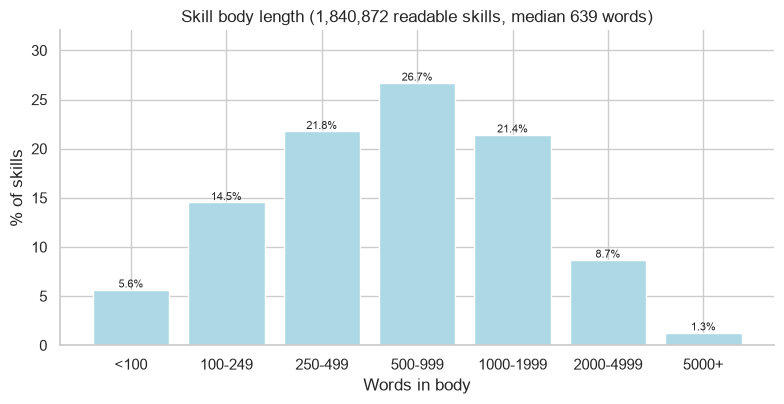

In [7]:
body_length["pct"] = 100 * body_length.skills / body_length.skills.sum()

median_words = con.execute(f"SELECT median(body_words) FROM '{skill_features_path}'").fetchone()[0]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(body_length.words, body_length.pct, color="lightblue")
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in body_length.pct], fontsize=8)
ax.set_xlabel("Words in body"); ax.set_ylabel("% of skills")
ax.set_ylim(0, body_length.pct.max() * 1.2)
ax.set_title(f"Skill body length ({body_length.skills.sum():,} readable skills, median {median_words:.0f} words)")
plt.tight_layout()
plt.show()


#### Findings

On the readable population defined above (1,840,872 skills):

**Size.** A typical skill is a short document: the median body is 639 words,
with the middle half between 306 and 1,183 words. Seven in ten skills (70%)
fall between 250 and 2,000 words; 5.6% are under 100 words and 1.3% exceed
5,000. The median description is 188 characters, and at least 10% of skills
have none, mostly those with invalid front matter.

**Structure.** Skills are highly structured Markdown. The median skill has 12
headings, and only 1.7% have none. Most use bullet lists (94%), numbered steps
(70%) and code blocks (68%); 44% include tables and 21% link to other
resources. Structure is so common that its presence cannot distinguish one
kind of skill from another; its amount and organization might.

**Named sections.** Sections suggested by the skill format are less common
than generic structure: 22% have an Examples or Usage section and 25% a
"When to use" section spelling out the trigger conditions the description is
meant to convey.

**Front matter.** Beyond the required `name` and `description`, optional
fields are rare: `allowed-tools` appears in 9.6% of skills, `license` in 11.5%,
and `version` or `metadata` in 24.8%. Tool restrictions, which limit what an
agent may do while using a skill, are declared by fewer than one in ten.

**Language.** 7.4% of skills are mostly non-English, which matters for
text-similarity methods built on English-language models.

**By location.**

| Location | Skills | Median words | Code blocks | Examples section | "When to use" |
|---|---|---|---|---|---|
| Generic `skills/` | 1,019,877 | 620 | 65.1% | 21.7% | 24.6% |
| Other paths | 554,589 | 636 | 69.0% | 24.5% | 29.3% |
| Canonical agent folder | 266,406 | 710 | 76.9% | 15.7% | 17.3% |

Skills in canonical agent folders are longer and more code-heavy, but include
Examples and "When to use" sections less often. Skills in generic directories
more often come from published collections, which follow a fuller template
with explicit usage and trigger sections; skills written in place inside an
agent project are more working documents, with more code and less
presentation.

**Caveat.** Features are regex-based approximations; for example, a line
starting with `#` inside a code block counts as a heading. The next section
splits the same features by the authorship label.


## Structural features by authorship label

The summaries above pool every readable skill. This section splits the same features by the authorship label defined in `EDA_authorship.ipynb`. The rules are rebuilt here so this notebook runs on its own:

- **highly_templated** — the same `file_sha` occurs in 10 or more files.
- **agent_assisted** — history was fetched, fewer than 6 representative skills share that repository and `first_commit_at`, and the first commit is a coding-agent bot or names an AI tool in a `Co-authored-by` trailer.
- **likely_human** — history was fetched, the skill was committed alone by a `User`, neither the first nor the last commit has an AI trailer, and the text occurs once.
- **insufficient_evidence** — everything else.

Batches of 6 or more are installs and do not count as agent-assisted or likely human. The table is the readable population only (body of at least 200 characters), so each class is slightly smaller than in the authorship notebook.


In [8]:
BULK_MIN = 6
TEMPLATE_MIN = 10
AGENTS  = r"copilot|devin|jules|opencode|^claude|lovable|kilo-code|codex|factory-droid|amazon-q|codegen|capy-ai|warp-dev|cursor"
DISTRIB = r"clawdhub|txtskills|skill"
LABEL_ORDER = ["likely_human", "agent_assisted", "highly_templated", "insufficient_evidence"]

def _trailer(column):
    needles = ("claude", "anthropic", "cursor", "copilot", "codex", "openai", "gemini")
    return " OR ".join(
        f"lower(coalesce({column}, '')) LIKE '%co-authored-by:%{name}%'" for name in needles
    )

con.execute(f"""
CREATE OR REPLACE TEMP TABLE skill_label AS
WITH copies AS (
  SELECT file_sha, COUNT(*) AS copy_files
  FROM read_parquet('{artifacts_path}')
  GROUP BY 1
),
batch AS (
  SELECT repo_full_name, first_commit_at, COUNT(*) AS batch_n
  FROM read_parquet('{artifacts_path}')
  WHERE dedup_primary = 1 AND history_fetched = 1
  GROUP BY 1, 2
),
s AS (
  SELECT a.file_sha,
         a.history_fetched = 1 AS has_history,
         a.first_commit_author_type,
         coalesce(b.batch_n, 0) AS batch_n,
         c.copy_files,
         CASE
           WHEN coalesce(a.first_commit_author_type, '') NOT IN ('Bot', 'ProgrammaticAccessBot')
             THEN 'not a bot'
           WHEN lower(coalesce(a.first_commit_author, '')) IN ('github-actions[bot]', 'dependabot[bot]', 'renovate[bot]')
             OR lower(coalesce(a.first_commit_author, '')) LIKE '%release%'
             OR lower(coalesce(a.first_commit_author, '')) LIKE '%sync%'
             THEN 'CI, release and sync'
           WHEN regexp_matches(lower(coalesce(a.first_commit_author, '')), '{AGENTS}')
             THEN 'Coding agents'
           WHEN regexp_matches(lower(coalesce(a.first_commit_author, '')), '{DISTRIB}')
             THEN 'Skill distribution'
           ELSE 'Other project bots'
         END AS bot_group,
         ({_trailer('a.first_commit_message')}) AS ai_first,
         ({_trailer('a.last_commit_message')}) AS ai_last
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN batch b
    ON b.repo_full_name = a.repo_full_name
   AND b.first_commit_at = a.first_commit_at
  JOIN copies c ON c.file_sha = a.file_sha
  WHERE a.dedup_primary = 1
)
SELECT file_sha,
       CASE
         WHEN copy_files >= {TEMPLATE_MIN} THEN 'highly_templated'
         WHEN has_history AND batch_n < {BULK_MIN}
          AND bot_group NOT IN ('CI, release and sync', 'Skill distribution', 'Other project bots')
          AND (bot_group = 'Coding agents' OR ai_first) THEN 'agent_assisted'
         WHEN has_history AND batch_n = 1
          AND first_commit_author_type = 'User'
          AND NOT ai_first AND NOT ai_last
          AND copy_files = 1
          AND bot_group = 'not a bot' THEN 'likely_human'
         ELSE 'insufficient_evidence'
       END AS label
FROM s
""")

structure_by_label = con.execute(f"""
SELECT l.label,
       COUNT(*) AS skills,
       CAST(median(f.body_words) AS INT) AS median_words,
       CAST(quantile_cont(f.body_words, 0.25) AS INT) AS words_p25,
       CAST(quantile_cont(f.body_words, 0.75) AS INT) AS words_p75,
       CAST(median(f.headings) AS INT) AS median_headings,
       CAST(median(f.code_blocks) AS INT) AS median_code_blocks,
       ROUND(100.0 * AVG((f.numbered_items > 0)::INT), 1) AS pct_numbered,
       ROUND(100.0 * AVG((f.bullet_items > 0)::INT), 1) AS pct_bullets,
       ROUND(100.0 * AVG((f.code_blocks > 0)::INT), 1) AS pct_code,
       ROUND(100.0 * AVG((f.table_rows > 0)::INT), 1) AS pct_tables,
       ROUND(100.0 * AVG((f.links > 0)::INT), 1) AS pct_links,
       ROUND(100.0 * AVG(f.has_examples_section::INT), 1) AS pct_examples,
       ROUND(100.0 * AVG(f.has_when_to_use::INT), 1) AS pct_when,
       ROUND(100.0 * AVG(f.fm_allowed_tools::INT), 1) AS pct_allowed_tools,
       ROUND(100.0 * AVG(f.fm_license::INT), 1) AS pct_license,
       ROUND(100.0 * AVG(f.fm_version_or_metadata::INT), 1) AS pct_version,
       ROUND(100.0 * AVG((f.non_ascii_ratio > 0.2)::INT), 1) AS pct_non_english
FROM read_parquet('{skill_features_path}') f
JOIN skill_label l ON l.file_sha = f.file_sha
GROUP BY 1
""").df()
structure_by_label["label"] = pd.Categorical(structure_by_label.label, LABEL_ORDER, ordered=True)
structure_by_label = structure_by_label.sort_values("label").assign(label=lambda d: d.label.astype(str))
structure_by_label.set_index("label").T


label,likely_human,agent_assisted,highly_templated,insufficient_evidence
skills,61680.0,78947.0,34647.0,1665598.0
median_words,589.0,661.0,854.0,636.0
words_p25,286.0,322.0,395.0,305.0
words_p75,1016.0,1133.0,1415.0,1185.0
median_headings,10.0,11.0,18.0,12.0
median_code_blocks,2.0,2.0,4.0,2.0
pct_numbered,70.1,70.9,69.2,69.9
pct_bullets,93.2,93.5,95.0,94.0
pct_code,70.2,76.6,76.3,67.3
pct_tables,38.9,45.9,50.7,44.2


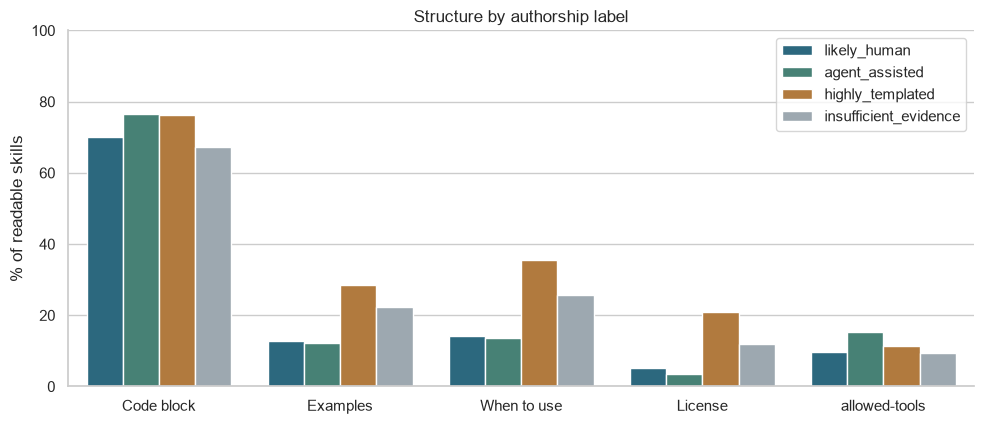

In [9]:
share_cols = ["pct_code", "pct_examples", "pct_when", "pct_license", "pct_allowed_tools"]
share_names = ["Code block", "Examples", "When to use", "License", "allowed-tools"]
long = structure_by_label.melt(id_vars="label", value_vars=share_cols, var_name="feature", value_name="pct")
long["feature"] = long.feature.map(dict(zip(share_cols, share_names)))
fig, ax = plt.subplots(figsize=(10, 4.4))
sns.barplot(data=long, x="feature", y="pct", hue="label", hue_order=LABEL_ORDER,
            palette=[ACCENT, "#3D8B7A", "#C47B2B", GREY], ax=ax)
ax.set_xlabel("")
ax.set_ylabel("% of readable skills")
ax.set_ylim(0, 100)
ax.legend(title="", loc="upper right")
ax.set_title("Structure by authorship label")
plt.tight_layout(); plt.show()


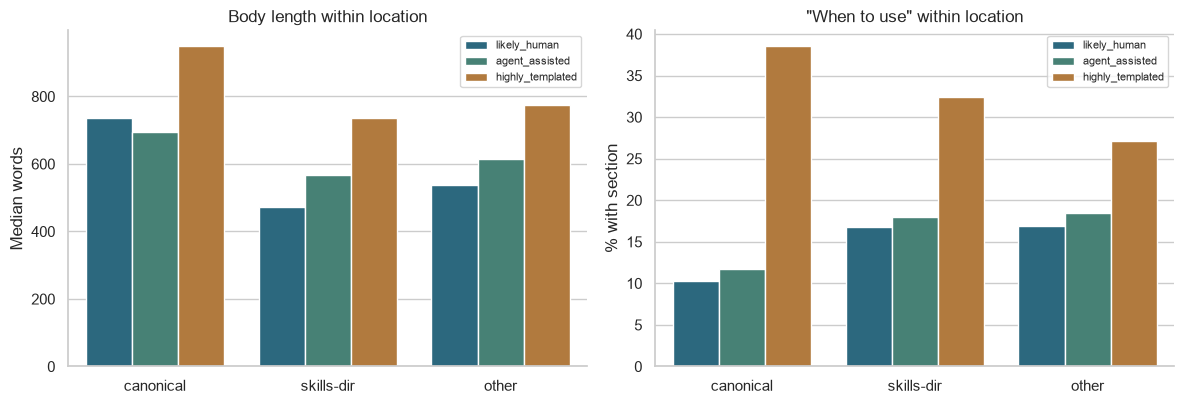

,label,location_class,skills,median_words,pct_code,pct_examples,pct_when,pct_allowed_tools
6,likely_human,canonical,26416,736,78.2,11.6,10.3,13.9
5,likely_human,skills-dir,26436,472,63.7,13.5,16.8,7.0
4,likely_human,other,8828,537,65.7,15.1,16.9,5.0
7,agent_assisted,canonical,56675,694,79.1,11.8,11.7,16.3
8,agent_assisted,skills-dir,17009,567,70.0,13.1,18.0,14.0
3,agent_assisted,other,5263,616,70.4,16.3,18.5,10.7
2,highly_templated,canonical,19310,948,77.3,27.3,38.5,9.3
1,highly_templated,skills-dir,13307,736,75.1,30.7,32.4,14.0
0,highly_templated,other,2030,774,75.3,26.0,27.1,15.5


In [10]:
structure_by_label_location = con.execute(f"""
SELECT l.label, f.location_class, COUNT(*) AS skills,
       CAST(median(f.body_words) AS INT) AS median_words,
       ROUND(100.0 * AVG((f.code_blocks > 0)::INT), 1) AS pct_code,
       ROUND(100.0 * AVG(f.has_examples_section::INT), 1) AS pct_examples,
       ROUND(100.0 * AVG(f.has_when_to_use::INT), 1) AS pct_when,
       ROUND(100.0 * AVG(f.fm_allowed_tools::INT), 1) AS pct_allowed_tools
FROM read_parquet('{skill_features_path}') f
JOIN skill_label l ON l.file_sha = f.file_sha
WHERE l.label <> 'insufficient_evidence'
GROUP BY 1, 2
""").df()
loc_order = ["canonical", "skills-dir", "other"]
three = ["likely_human", "agent_assisted", "highly_templated"]
structure_by_label_location["label"] = pd.Categorical(structure_by_label_location.label, three, ordered=True)
structure_by_label_location["location_class"] = pd.Categorical(
    structure_by_label_location.location_class, loc_order, ordered=True)
structure_by_label_location = structure_by_label_location.sort_values(["label", "location_class"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col, ylabel, title in [
    (axes[0], "median_words", "Median words", "Body length within location"),
    (axes[1], "pct_when", "% with section", '"When to use" within location'),
]:
    sns.barplot(data=structure_by_label_location, x="location_class", y=col, hue="label",
                order=loc_order, hue_order=three, palette=[ACCENT, "#3D8B7A", "#C47B2B"], ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title="", fontsize=8)
plt.tight_layout(); plt.show()
structure_by_label_location.assign(
    label=lambda d: d.label.astype(str),
    location_class=lambda d: d.location_class.astype(str),
)


#### Findings by authorship label

On the readable population, the four labels cover 61,680 likely-human skills, 78,947 agent-assisted, 34,647 highly templated, and 1,665,598 with insufficient evidence.

**Shared structure does not separate the classes.** Numbered steps are present in 69–71% of every class, and bullets in 93–95%. A skill that uses lists is not evidence of who wrote it.

**Highly templated skills have a different shape.** The median body is 854 words, against 589 for likely human and 661 for agent-assisted, and the median heading count is 18 against 10 and 11. An Examples section appears in 28.5% (12.9% and 12.3%), a "When to use" section in 35.5% (14.1% and 13.5%), a `license` field in 20.8% (5.2% and 3.6%), and `version` or `metadata` in 34.4% (12.0% and 10.6%). They are also the least often mostly non-English (2.7%, against 9.2% and 10.7%). The middle half of templated bodies still overlaps the others (395–1,415 words, against 286–1,016 for likely human), so length alone does not classify a single skill. The section pattern does the separating.

**Agent-assisted and likely human stay close.** Examples and "When to use" match. Agent-assisted skills more often contain a code block (76.6% versus 70.2%) and declare `allowed-tools` (15.4% versus 9.7%). Word-count distributions overlap (middle half 322–1,133 versus 286–1,016).

**Most of that small gap is location.** Of readable agent-assisted skills, 56,675 of 78,947 (71.8%) sit in a canonical agent folder, against 26,416 of 61,680 (42.8%) of likely-human skills. Inside canonical folders the two classes match: median 694 versus 736 words, code blocks 79.1% versus 78.2%, Examples 11.8% versus 11.6%, "When to use" 11.7% versus 10.3%, and `allowed-tools` 16.3% versus 13.9%. Inside generic `skills/` directories a smaller gap remains (median 567 versus 472 words, code blocks 70.0% versus 63.7%, `allowed-tools` 14.0% versus 7.0%). Highly templated skills stay longer and keep the extra Examples and "When to use" sections in every location, so that difference is not a location effect.

Insufficient-evidence skills fall between the singleton human texts and the highly templated ones on Examples (22.3%) and "When to use" (25.7%). That group mixes skills with no history, bulk installs, and texts copied fewer than 10 times.
